# An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale

)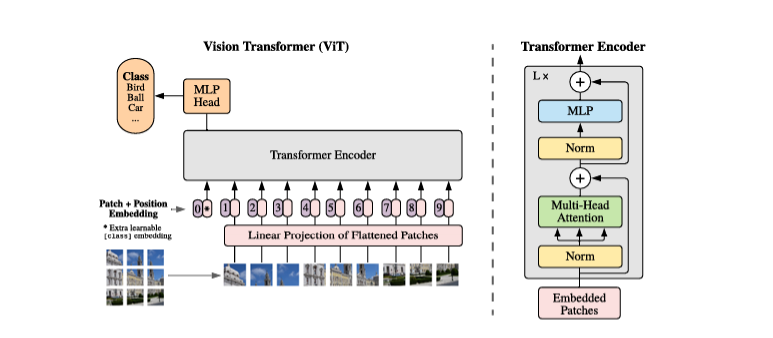

In [ ]:
### image => (3,224,224)
## patch size => 16x16
### division := 224/16 => 14
## individual patch => (3,16,16) = 14x14 => 196 patches (total number of patches)
### individaul patch : flatten => 3x16x16 => 786 dim vector for each patch

In [ ]:
import torch
import torch.nn as nn

In [ ]:
image = torch.zeros(3,27,27)
patches = 9

### Lets build the patches convulation layer

In [ ]:
projection = nn.Conv2d(
    in_channels = 3,
    out_channels = 27,
    kernel_size = 3,
    stride = 3
)

In [ ]:
projection(image).shape

torch.Size([27, 9, 9])

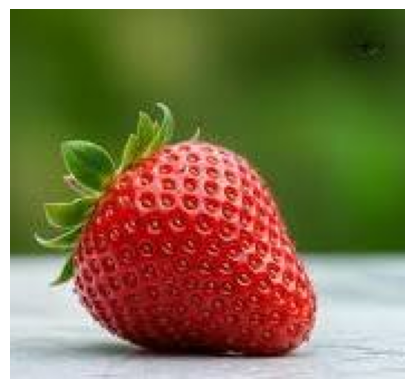

In [ ]:
### lets test on original image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('/content/image.jpg')

plt.imshow(img)
plt.axis('off') # Optional: hides the X and Y axes
plt.show()

In [ ]:
from PIL import Image
import numpy as np
img = Image.open("/content/image.jpg")
img = np.array(img.resize((27,27)))
img = img.transpose(2,0,1)
img.shape

(3, 27, 27)

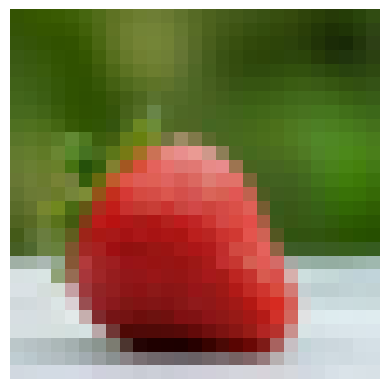

In [ ]:
plt.imshow(img.transpose(1,2,0))
plt.axis('off') # Optional: hides the X and Y axes
plt.show()

In [ ]:
img = torch.from_numpy(img)
img = img.to(torch.float32)

In [ ]:
projection(img).shape

torch.Size([27, 9, 9])

In [ ]:
img_proj = projection(img)

In [ ]:
img_proj[0].shape

torch.Size([9, 9])

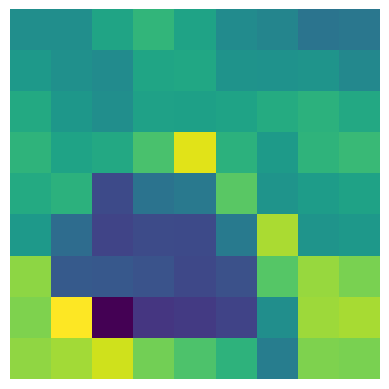

In [ ]:
plt.imshow(img_proj[0].detach().cpu().numpy())
plt.axis("off")
plt.show()

/tmp/ipython-input-1076917245.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


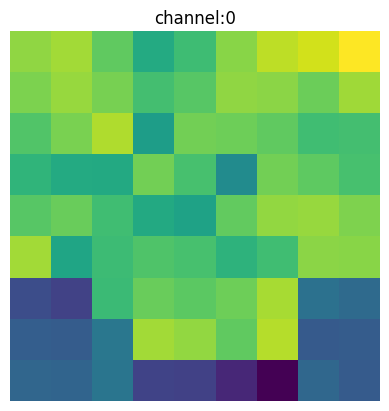

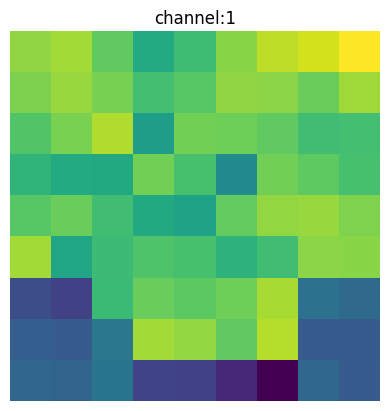

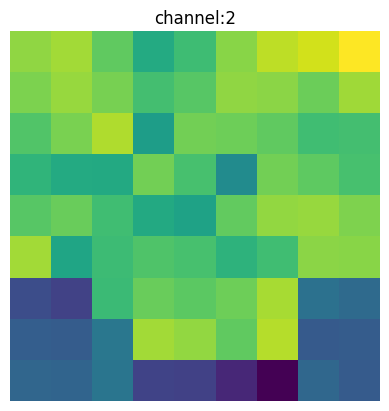

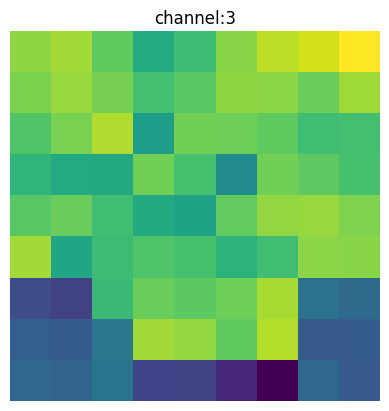

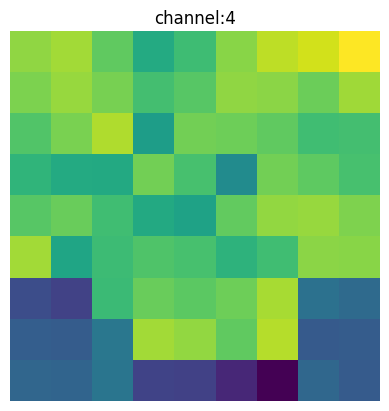

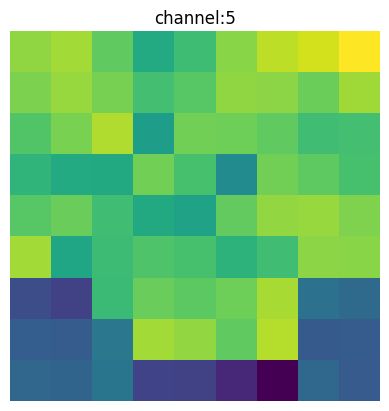

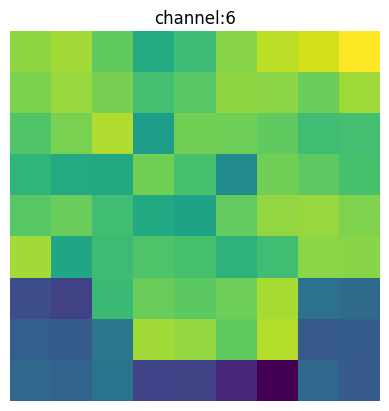

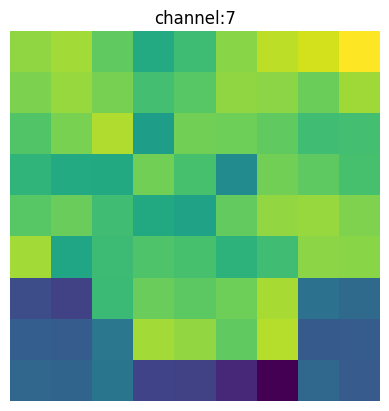

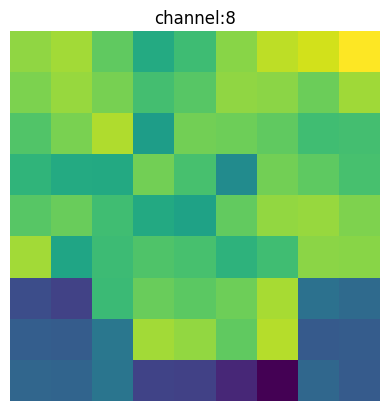

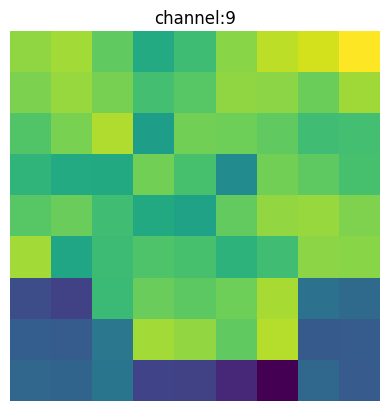

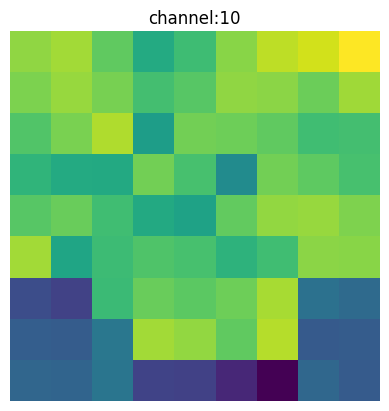

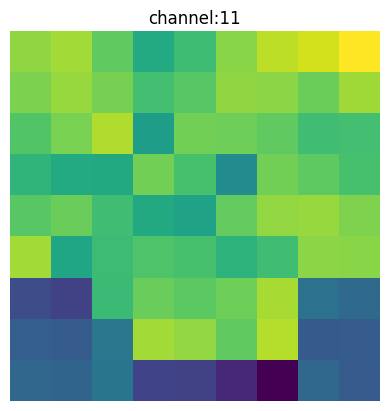

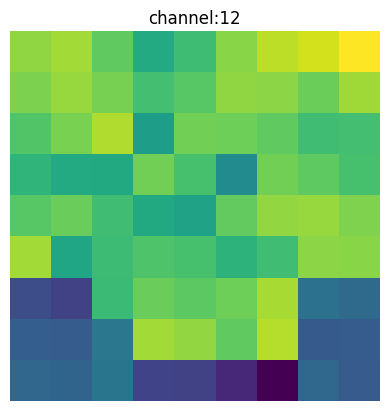

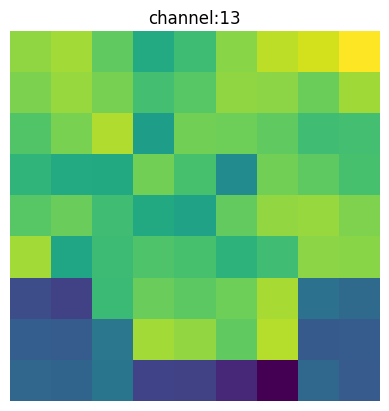

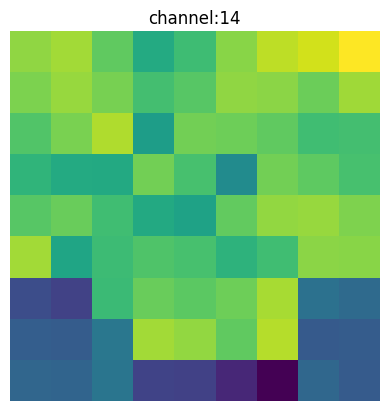

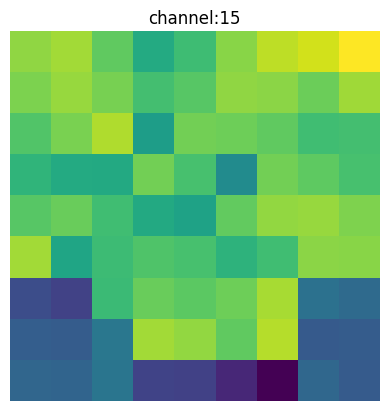

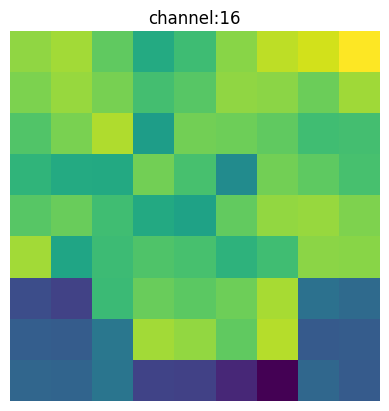

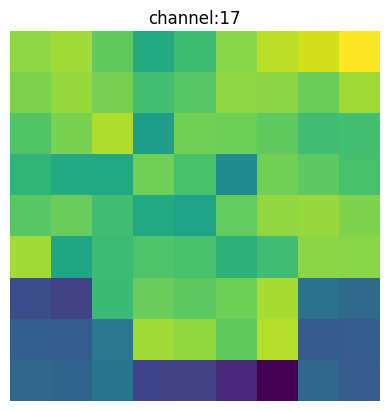

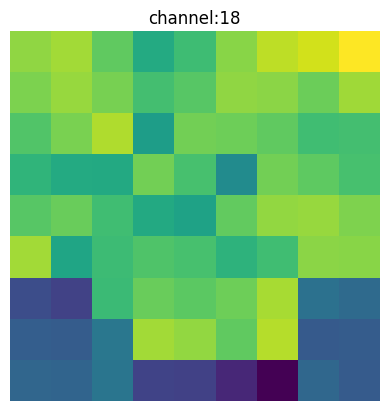

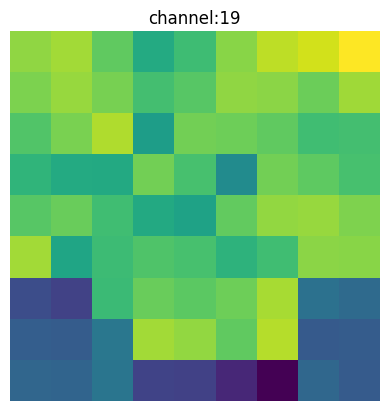

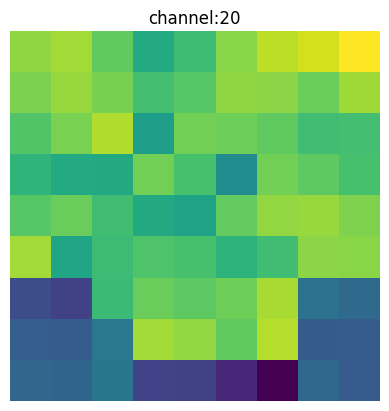

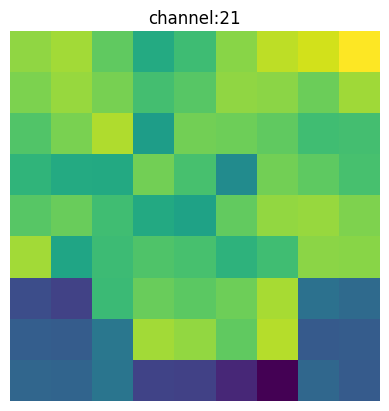

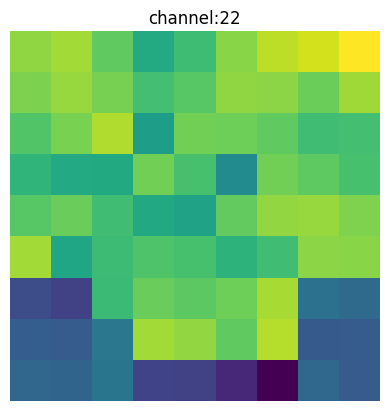

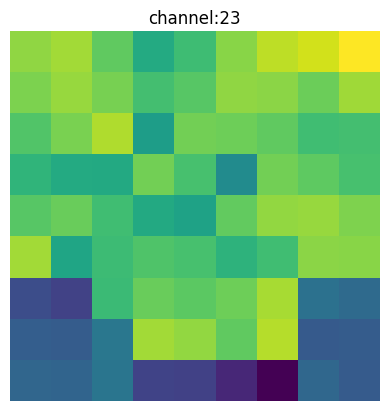

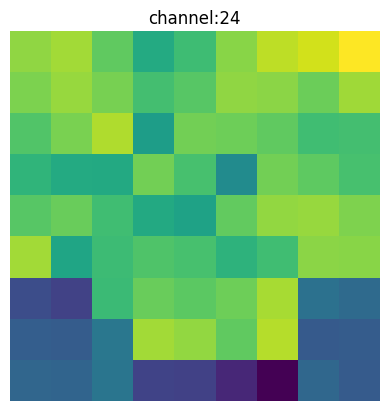

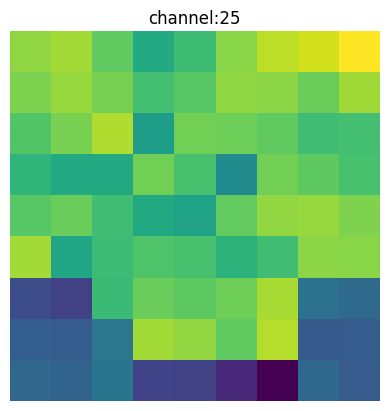

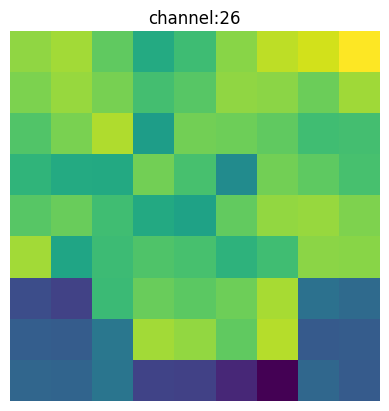

In [ ]:
for c in range(img_proj.shape[0]):
  plt.figure()
  plt.title(f"channel:{c}")
  plt.imshow(img_proj[0].detach().cpu().numpy())
  plt.axis("off")
plt.show()

In [ ]:
img_proj.shape

torch.Size([27, 9, 9])

In [ ]:
img_proj.view(27,81).transpose(0,1).shape

torch.Size([81, 27])

In [ ]:
img_proj.flatten(1,-1).shape # considering from first dimension to end dimension(-1)

torch.Size([27, 81])

In [ ]:
## for single image
img_swap = img_proj.view(27,81).transpose(0,1)

In [ ]:
img_swap.shape

torch.Size([81, 27])

In [ ]:
## adding the cls token
cls = torch.zeros(1,27)

In [ ]:
cls.shape

torch.Size([1, 27])

In [ ]:
input = torch.cat((img_swap,cls),dim=0) ## no addition
input.shape

torch.Size([82, 27])

## lets Build : Encoder block for this

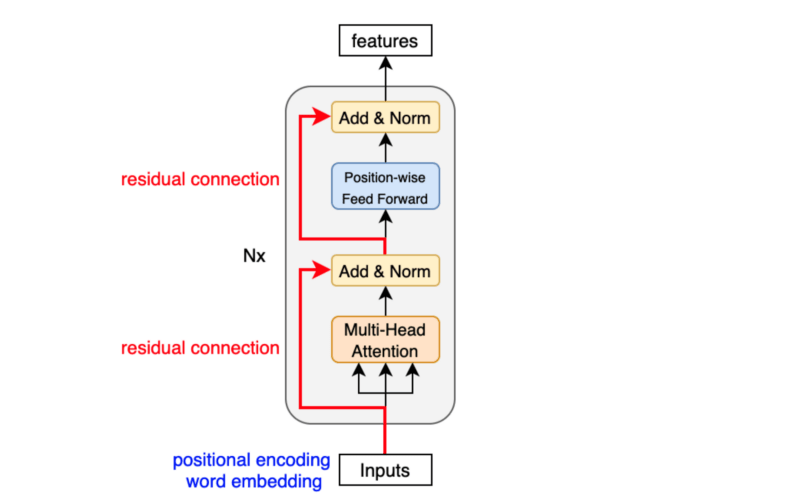

In [ ]:
img = torch.zeros(32,3,27,27)
img.shape

torch.Size([32, 3, 27, 27])

### lets build the inpu embedding : patch embedding for image

In [ ]:
class patchEmbedding(nn.Module):
  def __init__(self,patch_size,in_channels,embed_dim):
    super().__init__()
    self.proj = nn.Conv2d(
        in_channels = in_channels,
        out_channels = embed_dim,
        stride = patch_size,
        kernel_size = patch_size
    )
  def forward(self,x):
    ## assuming the shape of x = (batch size,channels,height,width)
    x = self.proj(x) # (batch_size,27,9,9)
    #print(x.shape)
    x = x.flatten(2,-1) # (batch,27,81)
    #print(x.shape)
    x = x.transpose(1,2) # (batch_size,81,27)
    return x

In [ ]:
input = patchEmbedding(3,3,27)
input

patchEmbedding(
  (proj): Conv2d(3, 27, kernel_size=(3, 3), stride=(3, 3))
)

In [ ]:
input(img).shape

torch.Size([32, 81, 27])

In [ ]:
img = input(img)

## lets build the function to add the cls tokent to each image

In [ ]:
img.shape

torch.Size([32, 81, 27])

In [ ]:
cls = nn.Parameter(torch.zeros(32,1,27))
cls.shape

torch.Size([32, 1, 27])

In [ ]:
img.shape

torch.Size([32, 81, 27])

In [ ]:
torch.cat((img,cls),dim=1).shape

torch.Size([32, 82, 27])

In [ ]:
input = torch.cat((img,cls),dim=1)
input.shape

torch.Size([32, 82, 27])

### let's build the : Positional Encoding class

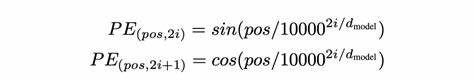

In [ ]:
import math
input = torch.zeros((32,197,768))
input.shape

torch.Size([32, 197, 768])

In [ ]:
class PositionalEncoding(nn.Module):
  def __init__(self,patches,embed_dim):
    super().__init__()
    ## img = (32,82,27) => (batch_size,patches,embed_dim)
    self.d_k = embed_dim
    self.patches = patches
    pe = torch.zeros(patches,self.d_k)
    div = torch.exp(torch.arange(0,self.d_k,2).float() * -(math.log(1000.0)/self.d_k)) # ()
    ### range(0,df-2,2) => 2i
    ### -(math.log(1000.0)/self.d_k) => -log(1000.0)/d_k
    ### multiplication => (2i/d_k) * -log(100.000)
    ### exp = -1000.0^(2i/d_k) => 1/1000.o^(2i/dk)
    position = torch.arange(0,patches).float().unsqueeze(1) # (82,1)
    pe[:,0::2] = torch.sin(position*div) # only even positions are taken
    pe[:,1::2] = torch.cos(position*div[:pe[:, 1::2].shape[1]]) # only the odd positions are taken
    pe = pe.unsqueeze(0) # adding the batch parameter
    self.register_buffer("pe",pe) # setting in the buffer to avoid the backtracking
  def forward(self,x):
    return x + (self.pe[:,:self.patches,:]).requires_grad_(False) # adding the positional vector => :self.patches are added to avoid the upscale in that dim

In [ ]:
positional = PositionalEncoding(197,768)

In [ ]:
positional(input).shape

torch.Size([32, 197, 768])

In [ ]:
positional_input = positional(input)

### lets Build the multihead attention block

In [ ]:
class MultiheadAttention(nn.Module):
  def __init__(self,patches,embed_dim):
    super().__init__()
    self.d_k = 9
    self.h = 3 # heads
    self.Q = nn.Linear(embed_dim,embed_dim)
    self.K = nn.Linear(embed_dim,embed_dim)
    self.V = nn.Linear(embed_dim,embed_dim)
    self.softmax = nn.Softmax(dim=-1)
    self.linear_fc = nn.Linear(embed_dim,embed_dim) # (27,27)
  def forward(self,x):
    batch,patch,embed = x.size()
    q = self.Q(x).view(batch,patch,self.h,self.d_k).transpose(1,2) ## (32,82,3,9)=>(32,3,82,9)
    k = self.K(x).view(batch,patch,self.h,self.d_k).transpose(1,2) ## (32,82,27)
    v = self.V(x).view(batch,patch,self.h,self.d_k).transpose(1,2) ## (32,82,27)
    print(q.shape)
    k_t = k.transpose(-2,-1) ## (32,27,82) => why -2,-1 := like replace the 82 with 27
    attention = self.softmax((q @ k_t)/math.sqrt(self.d_k)) @ v ## (32,3,82,9)
    print(attention.shape)
    out = attention.transpose(1,2).contiguous().view(batch,patch,embed) ## (32,82.27)
    print(out.shape)
    return self.linear_fc(out) # (32,82,27)

In [ ]:
attention = MultiheadAttention(82,27)

In [ ]:
attention

MultiheadAttention(
  (Q): Linear(in_features=27, out_features=27, bias=True)
  (K): Linear(in_features=27, out_features=27, bias=True)
  (V): Linear(in_features=27, out_features=27, bias=True)
  (softmax): Softmax(dim=-1)
  (linear_fc): Linear(in_features=27, out_features=27, bias=True)
)

In [ ]:
attention(positional_input).shape

torch.Size([32, 3, 82, 9])
torch.Size([32, 3, 82, 9])
torch.Size([32, 82, 27])


torch.Size([32, 82, 27])

In [ ]:
attention_input = attention(positional_input)

torch.Size([32, 3, 82, 9])
torch.Size([32, 3, 82, 9])
torch.Size([32, 82, 27])


### let's build the : Layer Norm Layer

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self):
    super().__init__()
    self.eps = 0.01
    self.alpha = nn.Parameter(torch.ones(1))
    self.beta = nn.Parameter(torch.ones(1))
    pass
  def forward(self,x):
    mean = x.mean(dim=-1,keepdim=True)
    std = x.std(dim=-1,keepdim=True)
    return (self.alpha * ((x - mean)/(std+self.eps))) + self.beta

In [ ]:
layer_norm = LayerNorm()
layer_norm

LayerNorm()

In [ ]:
layer_norm(attention_input).shape

torch.Size([32, 82, 27])

### let's build : Feed forward Layer

In [ ]:
class FeedForwardlayer(nn.Module):
  def __init__(self,patches,embed_dim):
    super().__init__()
    self.dim = 348
    self.fc_1 = nn.Linear(embed_dim,self.dim)
    self.fc_2 = nn.Linear(self.dim,embed_dim)
    self.relu = nn.ReLU()
  def forward(self,x):
    return self.fc_2(self.relu(self.fc_1(x)))

In [ ]:
fnn = FeedForwardlayer(82,27)
fnn

FeedForwardlayer(
  (fc_1): Linear(in_features=27, out_features=348, bias=True)
  (fc_2): Linear(in_features=348, out_features=27, bias=True)
  (relu): ReLU()
)

In [ ]:
fnn(attention_input).shape

torch.Size([32, 82, 27])

### Residual Connection layer

In [ ]:
class ResidualBlock(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm = LayerNorm()
  def forward(self,X,sublayer):
    print("in residual ")
    return X + sublayer(self.layer_norm(X)) # ada and norm
    ## here the sublayer is normed first then add

### lets build the encoder block

In [ ]:
### the input for the encoder block
## the flattedn image (patched) in dimension (batch,width,height)
## what enoder block has feed forward network , multihead attention ,residual block

In [ ]:
class EncoderBlock(nn.Module):
  def __init__(self,attention:MultiheadAttention,fnn:FeedForwardlayer,patches,embed_dim):
    super().__init__()
    self.attention = attention
    self.fnn = fnn
    self.patches = patches
    self.embed_dim = embed_dim
    self.residual = nn.ModuleList([ResidualBlock() for _ in range(2)]) # we want and 2 residual layer connected
  def forward(self,X):
    X = self.residual[0](X,lambda x:self.attention(X)) ## here the attention is second layer (sublayer) and the X is the input which is going to add
    X = self.residual[1](X,lambda x:self.fnn(X))
    return X

In [ ]:
attention = MultiheadAttention(82,27)
fnn = FeedForwardlayer(82,27)
encoder_ = EncoderBlock(attention,fnn,82,27)

In [ ]:
input.shape

torch.Size([32, 82, 27])

In [ ]:
encoder_(input).shape

in residual 
torch.Size([32, 3, 82, 9])
torch.Size([32, 3, 82, 9])
torch.Size([32, 82, 27])
in residual 


torch.Size([32, 82, 27])

In [ ]:
encoder_output = encoder_(input)

in residual 
torch.Size([32, 3, 82, 9])
torch.Size([32, 3, 82, 9])
torch.Size([32, 82, 27])
in residual 


In [ ]:
class Encoder(nn.Module):
  def __init__(self,layers:nn.ModuleList):
    super().__init__()
    self.layers = layers # Storing the EncoderBlocks
    self.norm = LayerNorm()

  def forward(self,X):
    for layer in self.layers:
      print("---------------------------------------------------------------")
      X = layer(X)
    return self.norm(X)

In [ ]:
encoder = Encoder(nn.ModuleList([encoder_ for _ in range(6)]))

In [ ]:
encoder(input).shape

---------------------------------------------------------------
in residual 
torch.Size([32, 3, 82, 9])
torch.Size([32, 3, 82, 9])
torch.Size([32, 82, 27])
in residual 
---------------------------------------------------------------
in residual 
torch.Size([32, 3, 82, 9])
torch.Size([32, 3, 82, 9])
torch.Size([32, 82, 27])
in residual 
---------------------------------------------------------------
in residual 
torch.Size([32, 3, 82, 9])
torch.Size([32, 3, 82, 9])
torch.Size([32, 82, 27])
in residual 
---------------------------------------------------------------
in residual 
torch.Size([32, 3, 82, 9])
torch.Size([32, 3, 82, 9])
torch.Size([32, 82, 27])
in residual 
---------------------------------------------------------------
in residual 
torch.Size([32, 3, 82, 9])
torch.Size([32, 3, 82, 9])
torch.Size([32, 82, 27])
in residual 
---------------------------------------------------------------
in residual 
torch.Size([32, 3, 82, 9])
torch.Size([32, 3, 82, 9])
torch.Size([32, 82, 27])

torch.Size([32, 82, 27])

In [ ]:
class ViTClassifier(nn.Module):
    def __init__(self, vit, num_classes):
        super().__init__()
        self.vit = vit
        self.head = nn.Sequential(
            nn.LayerNorm(vit.embed_dim),
            nn.Linear(vit.embed_dim, 2048),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        features = self.vit(x)[:, 0]  # CLS token
        return self.head(features)

In [ ]:
class_ = classifier = ViTClassifier(encoder_,10)

In [ ]:
class_(encoder_output).shape

in residual 
torch.Size([32, 3, 82, 9])
torch.Size([32, 3, 82, 9])
torch.Size([32, 82, 27])
in residual 


torch.Size([32, 10])

done